# 05 – V14 Pipeline Vizuális Demo

**Célja:** Véletlenszerűen kiválasztott képeken bemutatni a V14 pipeline vizualizációit egy
"dashboard" jellegű rácsban:

| Oszlop | Tartalom |
|---|---|
| **A** | Eredeti kép |
| **B** | Köztes fázisok: Canny (top) + Hough (bottom) |
| **C** | Kombinált eredmény: fogólapkörvonal + bundvonalak + ujjak |

**Fontos:** Ez a notebook **kizárólag `src` modulokat** importál.
Vizualizációs logika (függvény/osztály) itt nem kerül definiálásra – minden
megjelenítési logika a `src.viz.PipelineVisualizer` osztályban van.

In [9]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
from pathlib import Path

# ── Kizárólag src/ modulok ──────────────────────────────────────────────────
from src.config import CFG, PATHS
from src.fretboard import run_v14_pipeline
from src.geometry import bgr2rgb
from src.viz import PipelineVisualizer

OUTPUT_DIR = PATHS['output_dir'] / '05_visual_demo'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Setup OK')

Setup OK


## 1. Képek kiválasztása

A train split-ből véletlenszerűen, legalább 5 különböző osztályból 1-1 kép.
A kiválasztás reprodukálható (`random_state=42`).

In [10]:
manifest = pd.read_csv(PATHS['manifest'])

# Train split-ből 1-1 kép az első 8 osztályból (reprodukálható)
train_df = manifest[manifest['split'] == 'train'].copy()
chosen = (
    train_df
    .sort_values('class')
    .groupby('class', group_keys=False)
    .apply(lambda g: g.sample(1, random_state=42))
    .reset_index(drop=True)
)

# Maximum 8 kép a dashboard mérete miatt
MAX_IMAGES = 8
chosen = chosen.head(MAX_IMAGES)

print(f'{len(chosen)} kép kiválasztva:')
print(chosen[['class', 'filename']].to_string(index=False))

8 kép kiválasztva:
  class                  filename
      A         1762212326133.jpg
      B IMG_20251102_024129_1.jpg
      C         1762212395194.jpg
      D         1762212432929.jpg
      E         1762212477984.jpg
      F IMG_20251102_023927_1.jpg
      G         1762212557956.jpg
No hand   IMG_20251102_023816.jpg


## 2. Pipeline futtatás

Minden képre lefuttatja a V14 pipeline-t. Az `img` mező a result dict-ben
tárolja az eredeti BGR képet – ez szükséges a vizualizációhoz.

In [11]:
results = []
for _, row in chosen.iterrows():
    entry = {
        'path':     row['path'],
        'class':    row['class'],
        'filename': row['filename'],
    }
    r = run_v14_pipeline(entry)
    results.append(r)
    status = 'OK' if r['ok'] else f"FAIL – {r['invalid_reason']}"
    lm_cnt = len(r['landmarks']) if r.get('landmarks') else 0
    coverage = f"{r['fit']['coverage_ratio']:.2f}" if r.get('fit') else '—'
    print(f"  [{row['class']}] {row['filename'][:30]:<30}  {status:<35}  lm={lm_cnt}  cov={coverage}")

  [outer_edges_v9] vonalak: 9 | bal outlier: nem | jobb outlier: nem
  [outer_edges_v9] Bal oldal bővítve: -30.5px
  [outer_edges_v9] Jobb oldal bővítve: +30.5px
  [outer_edges_v9] szétválasztás: 61.0px (klaszter: 101.7px | bővítés: 30.5px)
  [trapezoid_v9] span=2315.1px | w_start=61.0px | w_end=61.0px | area=146982px²
  [A] 1762212326133.jpg               FAIL – trapezoid_sanity: area_frac 0.009 ∉ (0.01, 0.5)  lm=21  cov=—
  [outer_edges_v9] vonalak: 3 | bal outlier: nem | jobb outlier: nem
  [outer_edges_v9] Bal oldal bővítve: -89.7px
  [outer_edges_v9] Jobb oldal bővítve: +89.7px
  [outer_edges_v9] szétválasztás: 432.9px (klaszter: 299.0px | bővítés: 89.7px)
  [trapezoid_v9] span=3376.2px | w_start=432.9px | w_end=432.9px | area=1520169px²
  [nut_detect_v10] median=1780 | left_peak=13138 | right_peak=9990
  [nut_detect_v10] nut találat: left oldal @ x=18px (ratio=7.38)
  [step7] Hough: 67 nyers vonal → szűrve: 18
  [step7] HoughLinesP → 8 klaszter (0 széles kizárva)
  [fret_fit v11]

## 3. Vizualizátor példányosítása

`PipelineVisualizer` konstruktorban minden megjelenítési paramétert explicit megadunk.
Az osztály nem támaszkodik modul-szintű globális változókra.

In [12]:
viz = PipelineVisualizer(
    neck_color       = (50, 220, 50),    # zöld – gitárnyak trapéz
    fret_color       = (80, 80, 240),    # piros – visszavetített bund vonalak
    landmark_color   = (0, 230, 230),    # cián – landmark pontok
    connection_color = (230, 160, 0),    # narancssárga – ujjcsontváz
    fingertip_color  = (0, 180, 255),    # kék – ujjhegyek
    hough_line_color = (0, 200, 120),    # zöld – Hough vonalak
    line_thickness   = 2,
    point_radius     = 6,
    font_scale       = 0.5,
)
print(f'PipelineVisualizer kész  |  neck_color={viz.neck_color}')

PipelineVisualizer kész  |  neck_color=(50, 220, 50)


## 4. Dashboard

Háromoszlopos grid képenként:
- **A oszlop** – Eredeti kép
- **B oszlop** – Köztes fázisok: Canny (felső) + Hough vonalak (alsó)
- **C oszlop** – Kombinált eredmény: trapézkörvonal + bundvonalak (visszavetítve) + MediaPipe ujjak

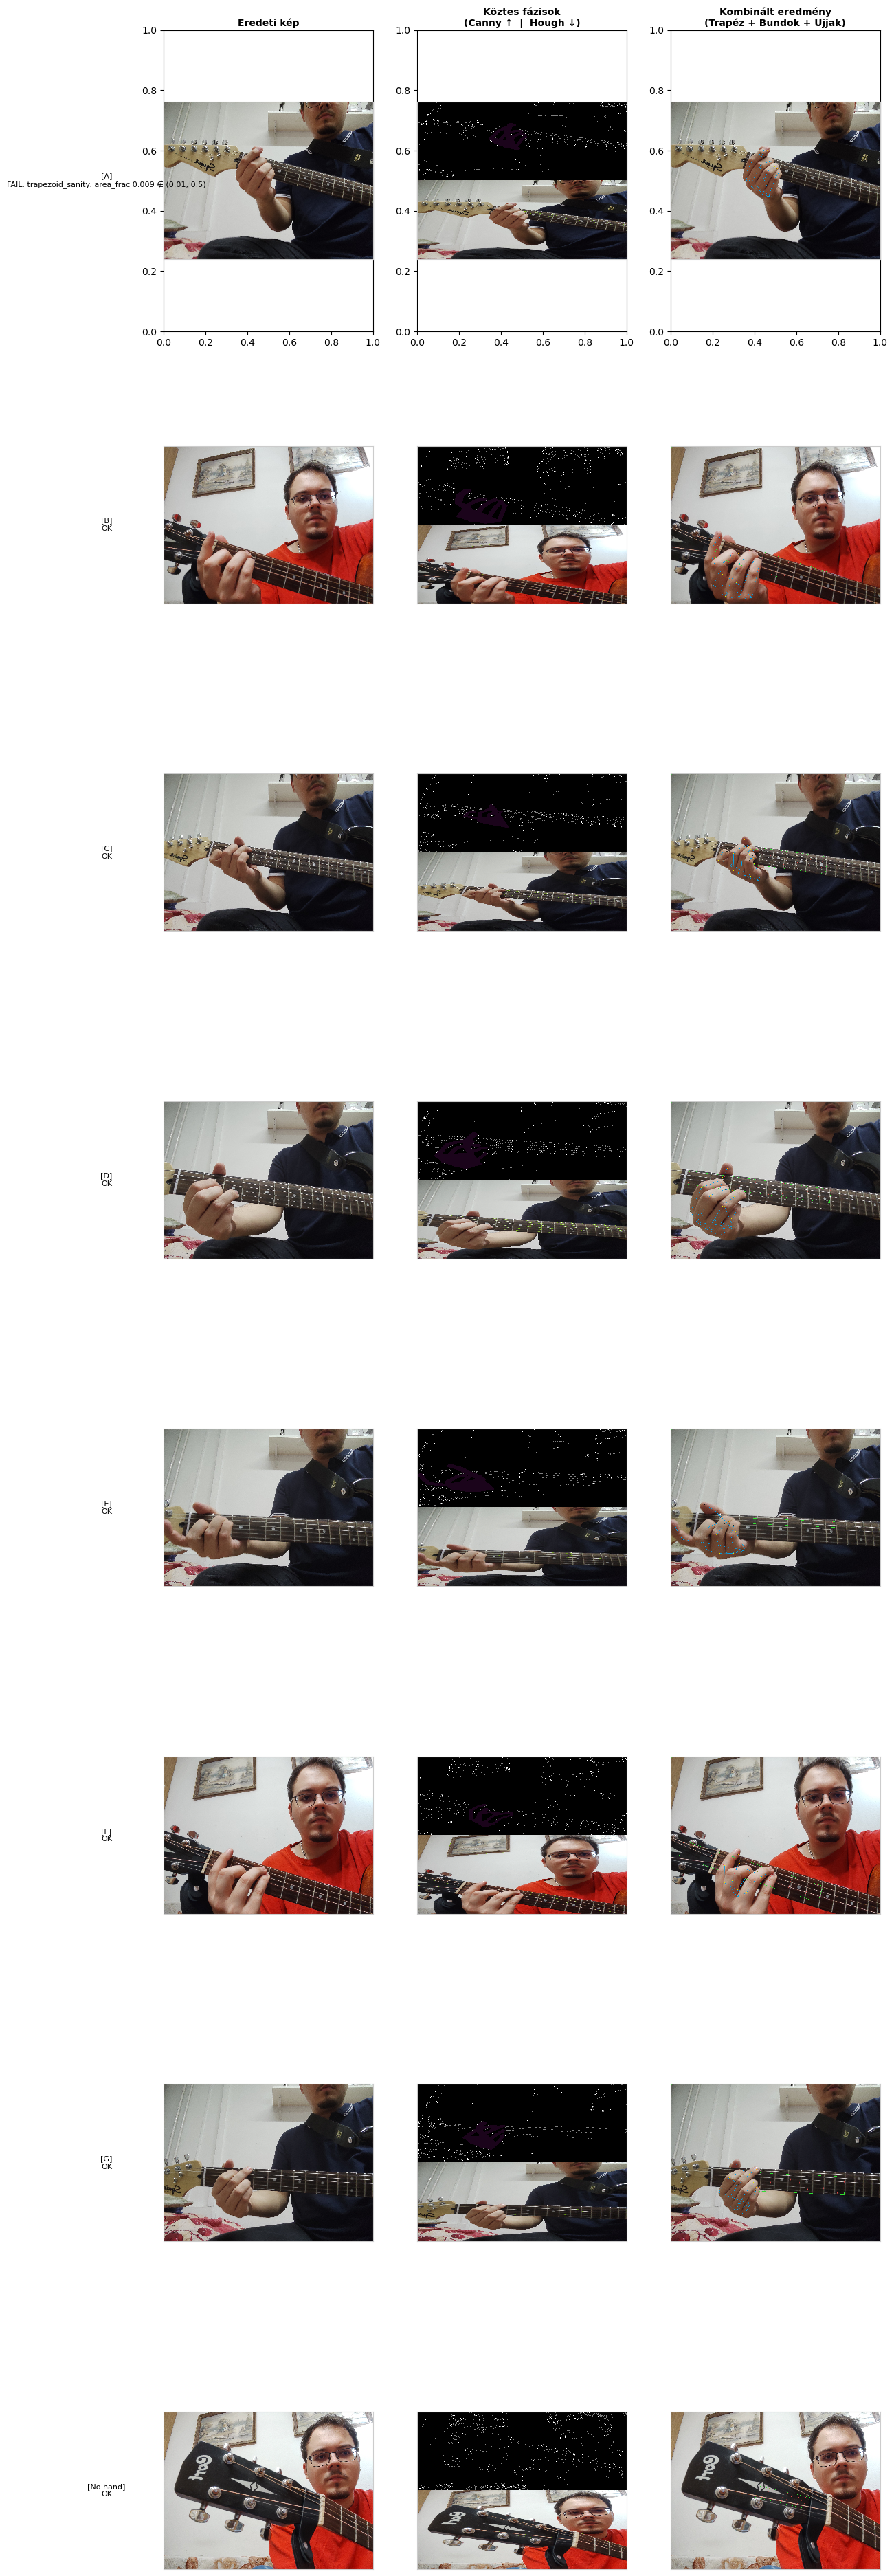

Dashboard mentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/05_visual_demo/dashboard.png


In [13]:
N = len(results)
ROW_H = 4.8      # sor magassága inch-ben
COL_W = [4.3, 4.3, 4.3]  # oszlop szélességek

fig = plt.figure(figsize=(sum(COL_W), ROW_H * N), constrained_layout=True)
gs  = gridspec.GridSpec(N, 3, figure=fig, wspace=0.05, hspace=0.08)

col_titles = [
    'Eredeti kép',
    'Köztes fázisok\n(Canny ↑  |  Hough ↓)',
    'Kombinált eredmény\n(Trapéz + Bundok + Ujjak)',
]

for col_i, title in enumerate(col_titles):
    fig.add_subplot(gs[0, col_i]).set_title(title, fontsize=10, fontweight='bold', pad=4)

for row_i, r in enumerate(results):
    img_bgr = r.get('img')
    if img_bgr is None:
        for col_i in range(3):
            ax = fig.add_subplot(gs[row_i, col_i])
            ax.text(0.5, 0.5, 'kép hiányzik', ha='center', va='center',
                    transform=ax.transAxes, color='gray')
            ax.axis('off')
        continue

    cls  = r.get('class', '?')
    ok   = r.get('ok', False)
    fname = r.get('filename', '')
    status_str = 'OK' if ok else f"FAIL: {r.get('invalid_reason','')}"

    # ── Oszlop A: Eredeti kép ──────────────────────────────────────────────
    ax_a = fig.add_subplot(gs[row_i, 0])
    ax_a.imshow(bgr2rgb(img_bgr), interpolation='nearest')
    ax_a.set_ylabel(f'[{cls}]\n{status_str}', fontsize=8, rotation=0,
                    labelpad=60, va='center')
    ax_a.set_xticks([])
    ax_a.set_yticks([])
    for spine in ax_a.spines.values():
        spine.set_edgecolor('#cccccc')

    # ── Oszlop B: Köztes fázisok (Canny + Hough csík) ─────────────────────
    ax_b = fig.add_subplot(gs[row_i, 1])
    finger_mask = r.get('finger_mask')  # már kiszámított a pipeline-ban
    phase_strip = viz.make_phase_strip(img_bgr, finger_mask=finger_mask)
    ax_b.imshow(bgr2rgb(phase_strip), interpolation='nearest')
    ax_b.set_xticks([])
    ax_b.set_yticks([])
    for spine in ax_b.spines.values():
        spine.set_edgecolor('#cccccc')

    # ── Oszlop C: Kombinált (Trapéz + Bundok + Ujjak) ────────────────────
    ax_c = fig.add_subplot(gs[row_i, 2])
    combined = img_bgr.copy()
    if ok:
        combined = viz.draw_fretboard_overlay(combined, r)
    landmarks = r.get('landmarks')
    if landmarks:
        combined = viz.draw_landmarks(combined, landmarks)
    ax_c.imshow(bgr2rgb(combined), interpolation='nearest')
    ax_c.set_xticks([])
    ax_c.set_yticks([])
    for spine in ax_c.spines.values():
        spine.set_edgecolor('#cccccc')

fig.savefig(OUTPUT_DIR / 'dashboard.png', dpi=220, bbox_inches='tight')
plt.show()
print(f'Dashboard mentve: {OUTPUT_DIR / "dashboard.png"}')

## 5. Kanonikus tér részletes nézet

Az OK-státuszú képek kanonikus (600×80 px) nézetét mutatja be a detektált
bundvonalakkal és az ujjhegyek pozícióival.

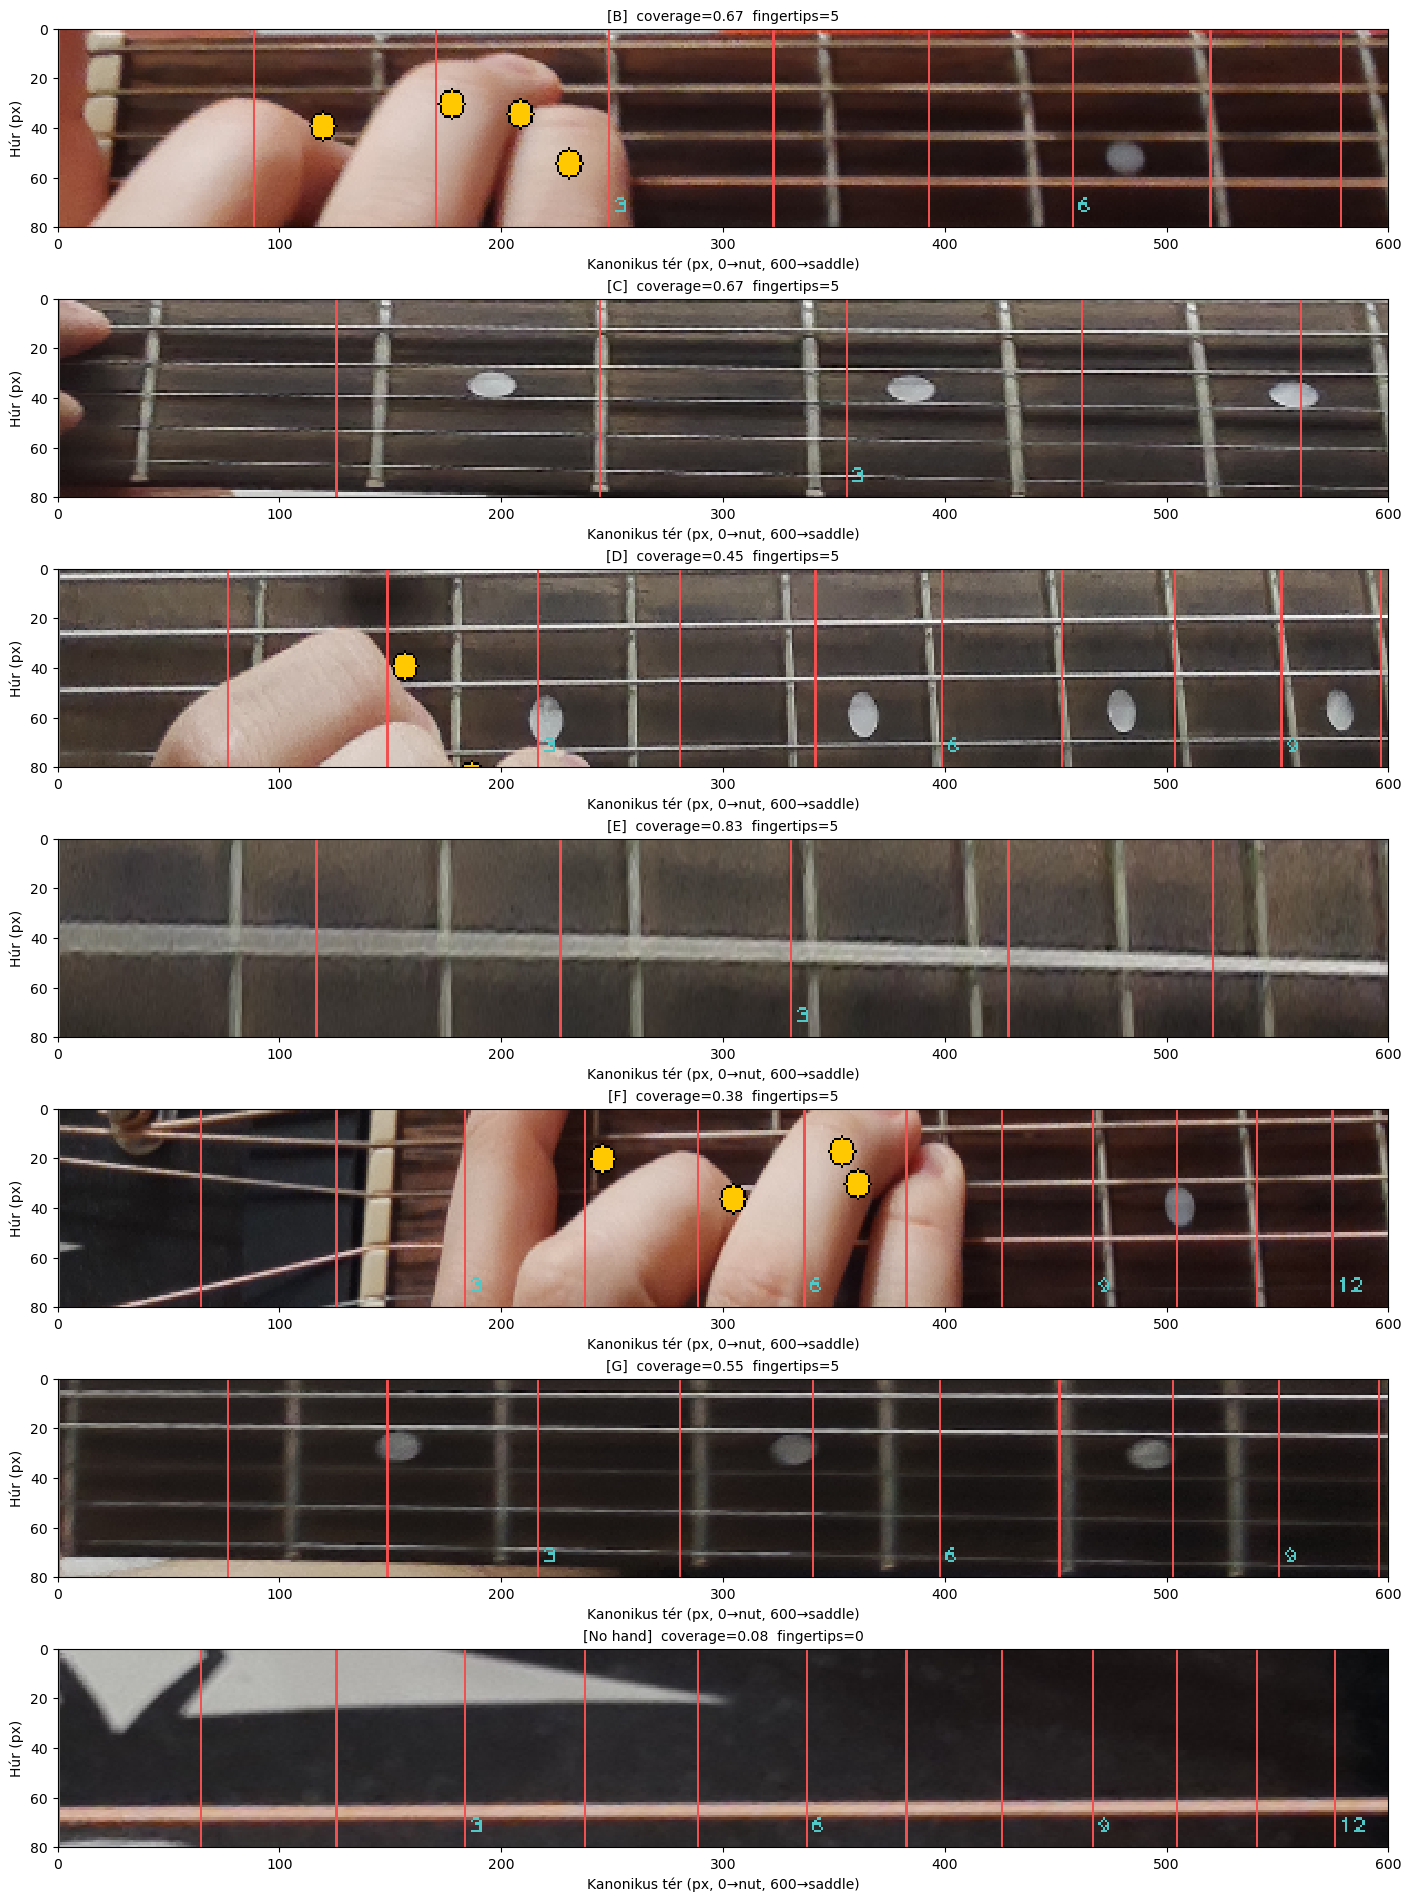

Kanonikus részletek mentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/05_visual_demo/canonical_detail.png


In [14]:
ok_results = [r for r in results if r.get('ok') and r.get('canon') is not None]

if not ok_results:
    print('Nincs OK-státuszú kép a kiválasztott mintában.')
else:
    n_ok = len(ok_results)
    fig2, axes2 = plt.subplots(n_ok, 1, figsize=(14, 2.7 * n_ok),
                                constrained_layout=True)
    if n_ok == 1:
        axes2 = [axes2]

    for ax, r in zip(axes2, ok_results):
        canon = r['canon'].copy()
        fit   = r.get('fit')

        # Bundvonalak a kanonikus képen (a viz modul segítségével)
        phases = viz.get_intermediate_plots(r['img'], r.get('finger_mask'))

        # Bundvonalak + ujjhegyek manuálisan a kanonikus képre
        if fit:
            for fret_n, fx in fit.get('predicted_x', {}).items():
                xi = int(round(float(fx)))
                cv2.line(canon, (xi, 0), (xi, 80), (80, 80, 240), 1)
                if int(fret_n) % 3 == 0 and int(fret_n) > 0:
                    cv2.putText(canon, str(int(fret_n)), (xi + 2, 74),
                                cv2.FONT_HERSHEY_PLAIN, 0.6, (200, 200, 80), 1)
        for ft in r.get('fingertips', []):
            cx = int(round(ft['canon_x']))
            cy = int(round(ft['canon_y']))
            cv2.circle(canon, (cx, cy), 5, (0, 200, 255), -1)
            cv2.circle(canon, (cx, cy), 6, (0, 0, 0), 1)

        ax.imshow(bgr2rgb(canon), aspect='auto', extent=[0, 600, 80, 0], interpolation='nearest')
        coverage = fit.get('coverage_ratio', 0) if fit else 0
        ax.set_title(
            f"[{r['class']}]  coverage={coverage:.2f}  "
            f"fingertips={len(r.get('fingertips', []))}",
            fontsize=10,
        )
        ax.set_xlabel('Kanonikus tér (px, 0→nut, 600→saddle)')
        ax.set_ylabel('Húr (px)')
        ax.grid(False)

    fig2.savefig(OUTPUT_DIR / 'canonical_detail.png', dpi=220, bbox_inches='tight')
    plt.show()
    print(f'Kanonikus részletek mentve: {OUTPUT_DIR / "canonical_detail.png"}')

## 6. PipelineVisualizer API – paraméter variánsok

Demonstrálja, hogy az osztály ugyanarra a képre különböző vizuális stílussal
példányosítható anélkül, hogy a forráskódban globális változót kellene módosítani.

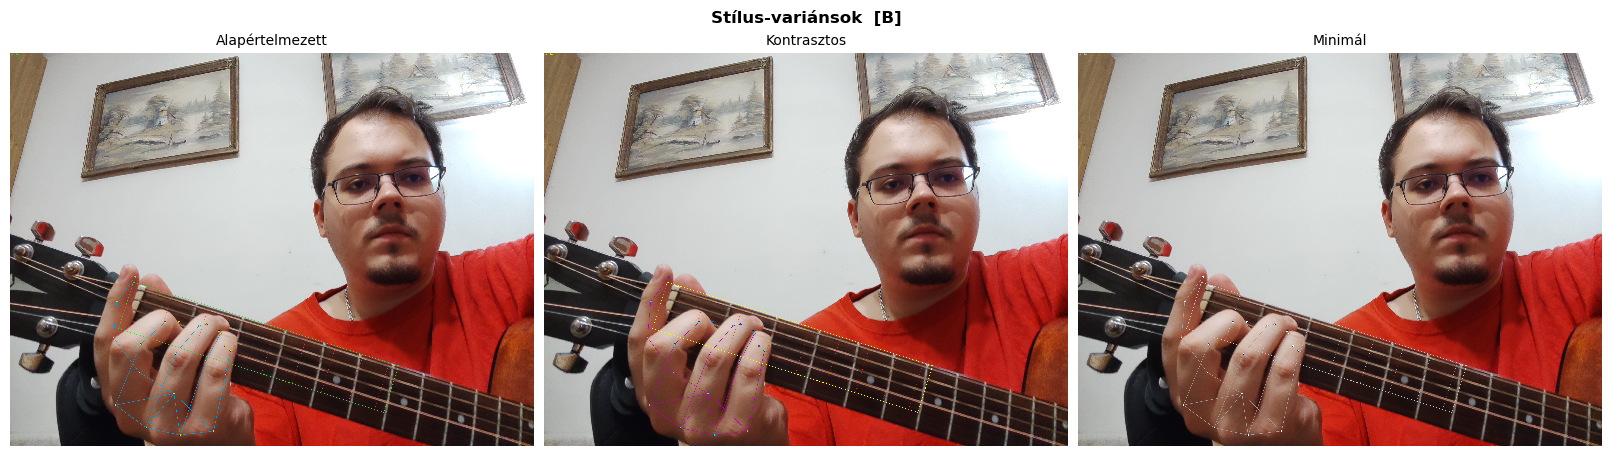

Stílus variánsok mentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/05_visual_demo/style_variants.png


In [ ]:
# Több demo kép, hogy a stílusvariánsok összehasonlítása ne csak egy mintán történjen
style_results = [r for r in results if r.get('img') is not None]
style_results = style_results[:4]

if not style_results:
    print('Nincs megjeleníthető kép a stílusvariánsokhoz.')
else:
    styles = [
        ('Alapértelmezett', dict(neck_color=(50,220,50),   fret_color=(80,80,240),
                                 landmark_color=(0,230,230), connection_color=(230,160,0),
                                 fingertip_color=(0,180,255))),
        ('Kontrasztos',     dict(neck_color=(0,255,255),   fret_color=(0,50,255),
                                 landmark_color=(255,255,0), connection_color=(180,0,180),
                                 fingertip_color=(255,100,0))),
        ('Minimál',         dict(neck_color=(200,200,200), fret_color=(200,200,200),
                                 landmark_color=(255,255,255), connection_color=(160,160,160),
                                 fingertip_color=(255,255,255))),
    ]

    n_rows = len(style_results)
    n_cols = len(styles)
    fig3, axes3 = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 4.2 * n_rows), constrained_layout=True)
    if n_rows == 1:
        axes3 = [axes3]

    fig3.suptitle('Stílus-variánsok több képen', fontsize=12, fontweight='bold')

    for row_i, demo_r in enumerate(style_results):
        demo_img = demo_r['img']
        row_label = f"[{demo_r.get('class', '?')}] {demo_r.get('filename', '')[:28]}"
        for col_i, (name, style_kwargs) in enumerate(styles):
            ax = axes3[row_i][col_i] if n_rows > 1 else axes3[col_i]
            v = PipelineVisualizer(**style_kwargs, line_thickness=2, point_radius=6)
            combined = demo_img.copy()
            if demo_r.get('ok'):
                combined = v.draw_fretboard_overlay(combined, demo_r)
            if demo_r.get('landmarks'):
                combined = v.draw_landmarks(combined, demo_r['landmarks'])
            ax.imshow(bgr2rgb(combined), interpolation='nearest')
            if row_i == 0:
                ax.set_title(name, fontsize=10)
            if col_i == 0:
                ax.set_ylabel(row_label, fontsize=8, rotation=0, labelpad=58, va='center')
            ax.axis('off')

    fig3.savefig(OUTPUT_DIR / 'style_variants.png', dpi=220, bbox_inches='tight')
    plt.show()
    print(f'Stílus variánsok mentve: {OUTPUT_DIR / "style_variants.png"}')

## 7. Összefoglalás

In [16]:
ok_cnt  = sum(1 for r in results if r.get('ok'))
lm_cnt  = sum(1 for r in results if r.get('landmarks'))
print('=== 05 Visual Demo – Összefoglalás ===')
print(f'Kiválasztott képek : {len(results)}')
print(f'Pipeline OK        : {ok_cnt}/{len(results)}')
print(f'Landmark detektált : {lm_cnt}/{len(results)}')
print()
print('Mentett fájlok:')
import os
for f in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(OUTPUT_DIR / f) // 1024
    print(f'  {f}  ({sz} KB)')

=== 05 Visual Demo – Összefoglalás ===
Kiválasztott képek : 8
Pipeline OK        : 7/8
Landmark detektált : 7/8

Mentett fájlok:
  canonical_detail.png  (1170 KB)
  dashboard.png  (6896 KB)
  style_variants.png  (1580 KB)
